<a href="https://colab.research.google.com/github/emilyb0/PaperModelosFinanacieros/blob/main/PaperCompCientifica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipykernel_14587/2501766090.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, period="1y")
[*********************100%***********************]  1 of 1 completed


========== RESULTADOS ==========

GBM + Milstein
MSE : 5789.437075396625
RMSE: 76.08835045785015

Modelo de Heston
MSE : 8959.458065245113
RMSE: 94.65441387090786


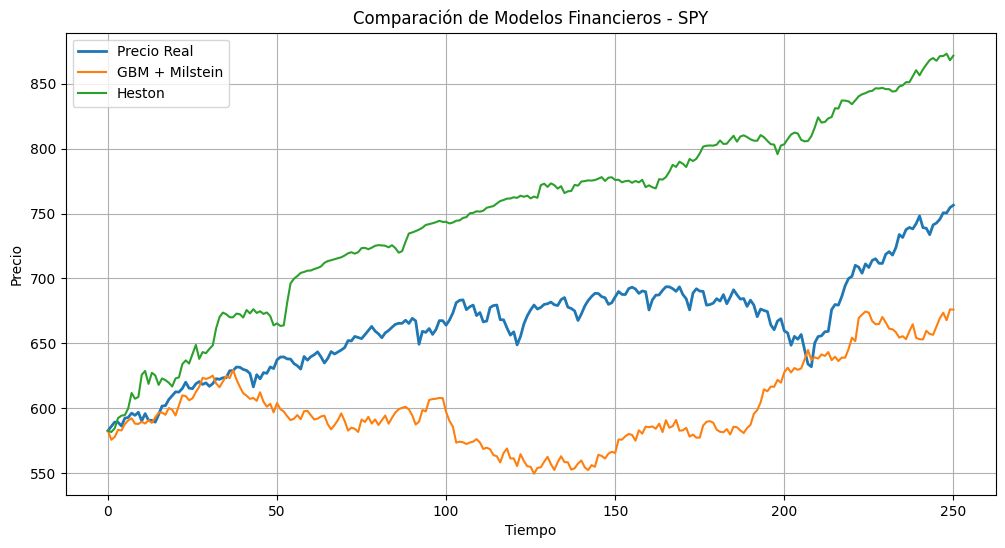

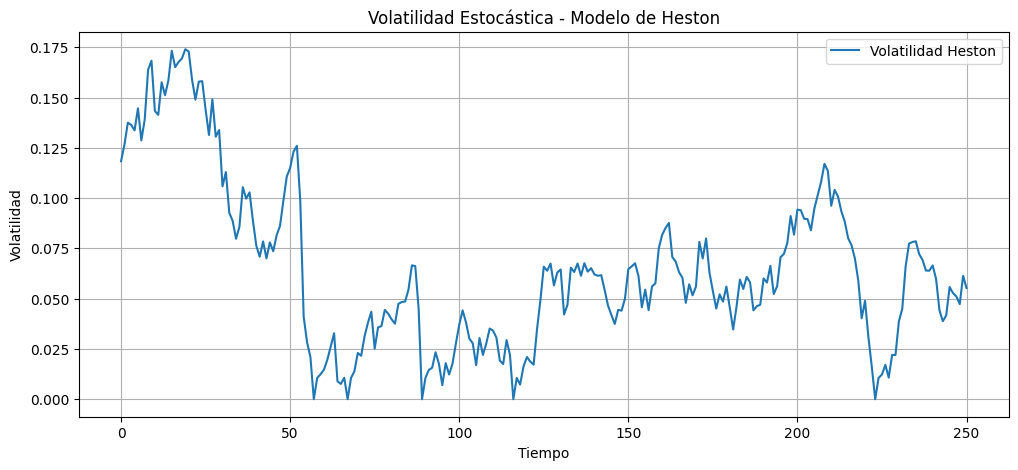

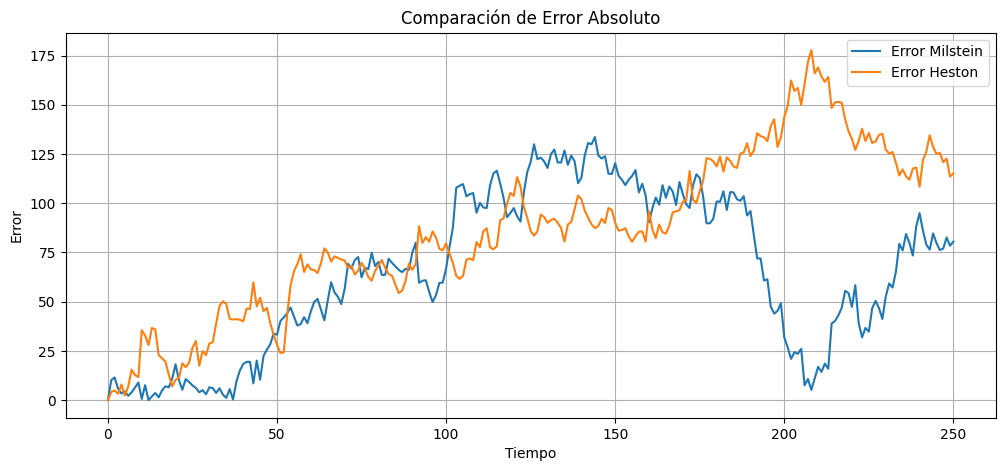

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

# ============================================================
# DESCARGA DE DATOS REALES
# ============================================================

ticker = "SPY"

data = yf.download(ticker, period="1y")

real_prices = data["Close"].values
real_prices = real_prices.flatten()

# ============================================================
# PARÁMETROS GENERALES
# ============================================================

np.random.seed(100)

S0 = float(real_prices[0])

T = 1

N = len(real_prices) - 1

dt = T / N

t = np.linspace(0, T, N + 1)

# ============================================================
# CÁLCULO DE RETORNOS Y VOLATILIDAD
# ============================================================

returns = np.diff(np.log(real_prices))

r = np.mean(returns) * 252

sigma = np.std(returns) * np.sqrt(252)

# ============================================================
# MODELO GBM + MILSTEIN
# ============================================================

def milstein_gbm(S0, r, sigma, T, N):

    dt = T / N

    t = np.linspace(0, T, N + 1)

    S = np.zeros(N + 1)

    S[0] = S0

    dW = np.random.normal(0, np.sqrt(dt), N)

    W = np.zeros(N + 1)

    W[1:] = np.cumsum(dW)

    for j in range(N):

        S[j + 1] = (
            S[j]
            + r * S[j] * dt
            + sigma * S[j] * dW[j]
            + 0.5 * sigma**2 * S[j] * (dW[j]**2 - dt)
        )

    return t, S


# ============================================================
# MODELO DE HESTON
# ============================================================

def heston_model(S0, v0, r, kappa, theta, xi, rho, T, N):

    dt = T / N

    t = np.linspace(0, T, N + 1)

    S = np.zeros(N + 1)

    v = np.zeros(N + 1)

    S[0] = S0

    v[0] = v0

    Z1 = np.random.normal(size=N)

    Z2 = np.random.normal(size=N)

    W1 = Z1

    W2 = rho * Z1 + np.sqrt(1 - rho**2) * Z2

    for j in range(N):

        v[j] = max(v[j], 0)

        v[j + 1] = (
            v[j]
            + kappa * (theta - v[j]) * dt
            + xi * np.sqrt(v[j]) * np.sqrt(dt) * W2[j]
        )

        v[j + 1] = max(v[j + 1], 0)

        S[j + 1] = (
            S[j]
            + r * S[j] * dt
            + np.sqrt(v[j]) * S[j] * np.sqrt(dt) * W1[j]
        )

    return t, S, v


# ============================================================
# PARÁMETROS DE HESTON
# ============================================================

v0 = sigma**2

kappa = 2.0

theta = sigma**2

xi = 0.3

rho = -0.7

# ============================================================
# SIMULACIONES
# ============================================================

t_milstein, S_milstein = milstein_gbm(
    S0,
    r,
    sigma,
    T,
    N
)

t_heston, S_heston, v_heston = heston_model(
    S0,
    v0,
    r,
    kappa,
    theta,
    xi,
    rho,
    T,
    N
)

# ============================================================
# MÉTRICAS DE ERROR
# ============================================================

mse_milstein = np.mean((real_prices - S_milstein) ** 2)

mse_heston = np.mean((real_prices - S_heston) ** 2)

rmse_milstein = np.sqrt(mse_milstein)

rmse_heston = np.sqrt(mse_heston)

print("========== RESULTADOS ==========")

print()

print("GBM + Milstein")

print("MSE :", mse_milstein)

print("RMSE:", rmse_milstein)

print()

print("Modelo de Heston")

print("MSE :", mse_heston)

print("RMSE:", rmse_heston)

# ============================================================
# GRÁFICA PRINCIPAL
# ============================================================

plt.figure(figsize=(12, 6))

plt.plot(
    real_prices,
    label="Precio Real",
    linewidth=2
)

plt.plot(
    S_milstein,
    label="GBM + Milstein"
)

plt.plot(
    S_heston,
    label="Heston"
)

plt.title(
    f"Comparación de Modelos Financieros - {ticker}"
)

plt.xlabel("Tiempo")

plt.ylabel("Precio")

plt.legend()

plt.grid()

plt.show()

# ============================================================
# VOLATILIDAD DE HESTON
# ============================================================

plt.figure(figsize=(12, 5))

plt.plot(
    np.sqrt(v_heston),
    label="Volatilidad Heston"
)

plt.title("Volatilidad Estocástica - Modelo de Heston")

plt.xlabel("Tiempo")

plt.ylabel("Volatilidad")

plt.legend()

plt.grid()

plt.show()

# ============================================================
# ERRORES
# ============================================================

error_milstein = np.abs(real_prices - S_milstein)

error_heston = np.abs(real_prices - S_heston)

plt.figure(figsize=(12, 5))

plt.plot(
    error_milstein,
    label="Error Milstein"
)

plt.plot(
    error_heston,
    label="Error Heston"
)

plt.title("Comparación de Error Absoluto")

plt.xlabel("Tiempo")

plt.ylabel("Error")

plt.legend()

plt.grid()

plt.show()